In [1]:
#Import relevant Python packages:
import CalculatedFieldSubroutines as cfs
import pandas as pd
from CalculatedFieldSubroutines import BinaryDrivingMode
import numpy as np
import os
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, balanced_accuracy_score
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


import cartopy.crs as ccrs

from cartopy.io.img_tiles import OSM, GoogleTiles, StadiaMapsTiles, MapQuestOSM

from pandasgui import show

#

import warnings


from sklearn import tree

#

from itertools import permutations

In [2]:
#Define the "ML_metrics" function, with "confusion_matrix_values" (containing the true positive, true negative,
#, false positive, and false negative) as the input
##Set "TP", "TN", "FP", "FN" equal to the "confusion_matrix_values
##Set "precision" equal to the quotient of "TP" and "TP + FP"
##Set "sensitivity" equal to the quotient of "TP" and "TP + FN"
##Set "specificity" equal to the quotient of "TN" and "TN + FP"
##Set "accuracy" equal to the quotient of "TP + TN" and "TP + TN + FP + FN"
##Set "balanced accuracy" equal to the quotient of "TP + TN" and "TP + TN + FP + FN"
def ML_metrics( confusion_matrix_values, display = False ):

    TP, TN, FP, FN = confusion_matrix_values

    #

    precision = TP / ( TP + FP )

    sensitivity = TP / ( TP + FN )

    specificity = TN / ( TN + FP )

    #

    accuracy = ( TP + TN ) / ( TP + TN + FP + FN )

    balanced_accuracy = ( sensitivity + specificity ) / 2

    if ( display == True ):

        print( f'True_Positives: { TP }, False_Positives: { FP }' )

        print( f'False_Negatives: { FN }, True_Negatives: { TN }' )

        print( '' )

        print( f'Precision: { precision:.3f}' )

        print( f'Sensitivity: { sensitivity:.3f}' )

        print( f'Specificity: { specificity:.3f}' )

        print( '' )

        print( f'Accuracy: { accuracy:.3f}' )

        print( f'Balanced_Accuracy: { balanced_accuracy:.3f}' )

    return TP, TN, FP, FN, precision, sensitivity, specificity, accuracy, balanced_accuracy

In [3]:
gmIDS=cfs.list_whitelisted_gmIDs_with_traffic_data()

In [4]:
RedgmIDs=[]
for gmID in gmIDS:
    if cfs.give_route(gmID)=="Red":
        RedgmIDs.append(gmID)
GreengmIDs=[]
for gmID in gmIDS:
    if cfs.give_route(gmID)=="Green":
        GreengmIDs.append(gmID)
BluegmIDs=[]
for gmID in gmIDS:
    if cfs.give_route(gmID)=="Blue":
        BluegmIDs.append(gmID)


In [5]:
#Create a "pandas" dataframe called "final_df"
final_df = pd.DataFrame()

In [6]:
#Print the sizes of "RedgmIDs", "GreengmIDs", "BluegmIDs"
print(len( RedgmIDs ))
print(len( GreengmIDs))
print(len ( BluegmIDs))

67
81
96


In [7]:
training_RedgmIDs_num = int(len( RedgmIDs ) * .8)
test_RedgmIDs_num = len( RedgmIDs) - training_RedgmIDs_num
print( training_RedgmIDs_num )
print( test_RedgmIDs_num )

53
14


In [8]:
training_GreengmIDs_num = int(len( GreengmIDs ) * .8)
test_GreengmIDs_num = len( GreengmIDs) - training_GreengmIDs_num
print( training_GreengmIDs_num )
print( test_GreengmIDs_num )

64
17


In [9]:
training_BluegmIDs_num = int(len( BluegmIDs ) * .8)
test_BluegmIDs_num = len( BluegmIDs) - training_BluegmIDs_num
print( training_BluegmIDs_num )
print( test_BluegmIDs_num )

76
20


In [10]:
#Set "red_training_dfs" equal to the following list of gmIDs
#Set "red_testing_dfs" equal to the list of gmIDs below "red_training_dfs"
red_training_dfs = ['61b12e7a-f234-11ee-bb33-fb353e7798cd',
 'fcc6fcd2-f013-11ee-b966-fb353e7798cd',
 '05c7c824-cab8-11ee-aa4d-1d66adf2f0c7',
 '211bdb36-f0da-11ee-ba1b-fb353e7798cd',
 '868de15e-f3b3-11ee-bb4e-fb353e7798cd',
 '72a03d4a-efe9-11ee-b966-fb353e7798cd',
 '7fb7b9c0-c881-11ee-a7fc-dd032dba19e8',
 '96f7a614-f549-11ee-8afa-cb629b0d53e6',
 '1bbbfbae-c839-11ee-a7fc-dd032dba19e8',
 '622bd2e8-f0e4-11ee-ba1f-fb353e7798cd',
 '9798fe24-f143-11ee-ba78-fb353e7798cd',
 '88dd6fbe-f224-11ee-bb21-fb353e7798cd',
 'c9c6856c-d33c-11ee-b437-336917683bb8',
 'd12cd1c4-caec-11ee-909c-e1dc60cf66f9',
 '817d6848-efb6-11ee-b966-fb353e7798cd',
 '1b6aca0e-efdf-11ee-b966-fb353e7798cd',
 '41b67a28-f52f-11ee-8afa-cb629b0d53e6',
 'fc211bb2-efca-11ee-b966-fb353e7798cd',
 '84d96f18-f214-11ee-bb13-fb353e7798cd',
 'fe973c9c-f53c-11ee-8afa-cb629b0d53e6',
 '3151e9e2-eff3-11ee-b966-fb353e7798cd',
 'c0555ef0-f50f-11ee-8afa-cb629b0d53e6',
 'f711e68e-f0e1-11ee-ba1f-fb353e7798cd',
 'c338788a-d324-11ee-b437-336917683bb8',
 'd21965e6-f0fa-11ee-ba37-fb353e7798cd',
 '88a68dd8-eef9-11ee-9385-ef789ffde1d3',
 'f41cbd44-eff8-11ee-b966-fb353e7798cd',
 '43a1a35e-f362-11ee-bb4e-fb353e7798cd',
 '6d2ea45a-c839-11ee-a7fc-dd032dba19e8',
 '01e65360-efd4-11ee-b966-fb353e7798cd',
 '7cbd932e-f244-11ee-bb3f-fb353e7798cd',
 '65cfbfd6-f396-11ee-bb4e-fb353e7798cd',
 '94c53148-eeed-11ee-9385-ef789ffde1d3',
 'fd1ab258-efa7-11ee-b966-fb353e7798cd',
 'e7b934a8-ef1a-11ee-9385-ef789ffde1d3',
 'de933de8-f112-11ee-ba4d-fb353e7798cd',
 'd3698592-ef9d-11ee-b966-fb353e7798cd',
 'dd72fdec-f0cf-11ee-ba0d-fb353e7798cd',
 'b82476fe-f1f3-11ee-baff-fb353e7798cd',
 'f755cf60-f132-11ee-ba6d-fb353e7798cd',
 '853ef120-cad3-11ee-909c-e1dc60cf66f9',
 'f0eebb6a-f0dc-11ee-ba1e-fb353e7798cd',
 'cf831f42-f353-11ee-bb4e-fb353e7798cd',
 'ecebb942-f162-11ee-ba97-fb353e7798cd',
 '219f7eb8-ef87-11ee-b966-fb353e7798cd',
 'd24820c8-f197-11ee-babe-fb353e7798cd',
 '3d2d29ec-ef95-11ee-b966-fb353e7798cd',
 '457dc5ee-f02a-11ee-b966-fb353e7798cd',
 '2462c9d0-eecd-11ee-9385-ef789ffde1d3',
 '51ef6da6-ca9f-11ee-909c-e1dc60cf66f9',
 'c25271be-f3a4-11ee-bb4e-fb353e7798cd',
 '8347b862-efad-11ee-b966-fb353e7798cd',
 '8dbbbf1c-f0ef-11ee-ba29-fb353e7798cd',
 '9189a2a8-f121-11ee-ba5b-fb353e7798cd',
 '8fa6fe80-c869-11ee-a7fc-dd032dba19e8']

red_testing_dfs = ['2a61b8a8-f528-11ee-8afa-cb629b0d53e6',
 'aa5dbcd2-ef10-11ee-9385-ef789ffde1d3',
 '171c50bc-f106-11ee-ba42-fb353e7798cd',
 'ce6465b6-f51b-11ee-8afa-cb629b0d53e6',
 '1ee938a2-f172-11ee-baa6-fb353e7798cd',
 'be857244-efc0-11ee-b966-fb353e7798cd',
 '286e019a-f204-11ee-bb07-fb353e7798cd',
 '2f95c748-f009-11ee-b966-fb353e7798cd',
 '35518ec4-f153-11ee-ba88-fb353e7798cd',
 '3344a3c0-f502-11ee-8afa-cb629b0d53e6',
 '8437f77a-cab7-11ee-909c-e1dc60cf66f9',
 'f43b6a70-f01e-11ee-b966-fb353e7798cd',
 '85b6e70e-ef7a-11ee-b966-fb353e7798cd',
 '5a4bccf4-effe-11ee-b966-fb353e7798cd']

In [11]:
len( red_testing_dfs )

5

In [12]:
seconds = 10
for id in RedgmIDs:
    if id in red_training_dfs:
        redtr_list = cfs.retrieve_gmID_preprocessed_moving_data(id,seconds)
    elif id in red_testing_dfs:
        redte_list = cfs.retrieve_gmID_preprocessed_moving_data(id,seconds)
    else:
        continue

In [13]:
X_name = ['brakePercentage', 'throttlePercentage', 'steeringPercentage', 'speedMps', 'LatLonTotalStdDev']
y_name = 'BinaryDrivingMode'
X_train_red = redtr_list[X_name]
X_test_red = redte_list[X_name]
y_train_red = redtr_list[y_name]
y_test_red = redte_list[y_name]

In [14]:
model_dt_red = tree.DecisionTreeClassifier( random_state = 0 )

model_dt_red = model_dt_red.fit( X_train_red, y_train_red )

#

y_pred_train_red = model_dt_red.predict( X_train_red )

y_pred_test_red = model_dt_red.predict( X_test_red )

redtr_list[ 'pred_BinaryDrivingMode' ] = y_pred_train_red

redte_list[ 'pred_BinaryDrivingMode' ] = y_pred_test_red


In [15]:
print( 'ML Metrics | Red Route | Testing Data (~80% of gmIDs) | No Max Tree Depth\n' )

metrics = ML_metrics( cfs.confusion_matrix_values( y_pred_test_red.astype( int ), 
                                                   y_test_red.astype( int ) ), 
                                                   display = True )

ML Metrics | Red Route | Testing Data (~80% of gmIDs) | No Max Tree Depth

True_Positives: 10400, False_Positives: 5473
False_Negatives: 8696, True_Negatives: 8254

Precision: 0.655
Sensitivity: 0.545
Specificity: 0.601

Accuracy: 0.568
Balanced_Accuracy: 0.573


In [16]:
#Set "green_training_dfs" equal to the following list of gmIDs
#Set "green_testing_dfs" equal to the list of gmIDs below "green_training_dfs"
green_training_dfs = ['3ec95686-f053-11ee-b988-fb353e7798cd',
 'b31aca98-cb95-11ee-909c-e1dc60cf66f9',
 '25e27b86-f06a-11ee-b9a3-fb353e7798cd',
 'bf9157f0-f16b-11ee-ba9e-fb353e7798cd',
 '51b74168-f19d-11ee-babf-fb353e7798cd',
 'de493be2-f10f-11ee-ba4b-fb353e7798cd',
 'ece2a8be-f047-11ee-b97d-fb353e7798cd',
 '044d976e-f0e5-11ee-ba20-fb353e7798cd',
 '98692fde-f1a4-11ee-bac6-fb353e7798cd',
 '5afabc8c-f035-11ee-b966-fb353e7798cd',
 '072ef896-cbac-11ee-909c-e1dc60cf66f9',
 'c59a54e0-f179-11ee-baab-fb353e7798cd',
 'bbbd0cc6-f0dc-11ee-ba1e-fb353e7798cd',
 'ba87f3ec-f07e-11ee-b9b4-fb353e7798cd',
 '96ceec56-f1cf-11ee-bae4-fb353e7798cd',
 '40706f50-f03b-11ee-b96e-fb353e7798cd',
 'f570c51c-f15d-11ee-ba91-fb353e7798cd',
 'f12112ba-f1c0-11ee-bada-fb353e7798cd',
 '961fd9cc-f103-11ee-ba3f-fb353e7798cd',
 '5f7ce340-f1c8-11ee-bae0-fb353e7798cd',
 'cf7148d8-f058-11ee-b98a-fb353e7798cd',
 '848e44a6-f134-11ee-ba6d-fb353e7798cd',
 '3a7dc9a6-f042-11ee-b974-fb353e7798cd',
 'c9be2042-f0de-11ee-ba1e-fb353e7798cd',
 '9736e77c-f187-11ee-bab6-fb353e7798cd',
 '5fc763f6-f1ab-11ee-bacd-fb353e7798cd',
 '4c88757c-f157-11ee-ba89-fb353e7798cd',
 'a231c0b0-f142-11ee-ba76-fb353e7798cd',
 '53fad09e-f0f7-11ee-ba2f-fb353e7798cd',
 '5c7a9ab2-f13b-11ee-ba72-fb353e7798cd',
 '4cf81634-f238-11ee-bb34-fb353e7798cd',
 'a08a8c7e-f1fb-11ee-bb05-fb353e7798cd',
 '3ed4aa16-f1d6-11ee-bae6-fb353e7798cd',
 '25135418-f250-11ee-bb4a-fb353e7798cd',
 'c1b320e2-f079-11ee-b9b0-fb353e7798cd',
 '43abeb00-f206-11ee-bb07-fb353e7798cd',
 'fe0395f0-f1ea-11ee-baf9-fb353e7798cd',
 '3d8020aa-cb7f-11ee-909c-e1dc60cf66f9',
 '14b6bc9c-f064-11ee-b998-fb353e7798cd',
 '870cfd32-f1b9-11ee-bad5-fb353e7798cd',
 'c2f54552-f06f-11ee-b9a9-fb353e7798cd',
 'dea29156-f123-11ee-ba5d-fb353e7798cd',
 '3c415ade-d353-11ee-b437-336917683bb8',
 'a901fe40-f0fd-11ee-ba39-fb353e7798cd',
 'c4146d46-f074-11ee-b9ac-fb353e7798cd',
 'de226278-f25a-11ee-bb4e-fb353e7798cd',
 'd7cb9c92-f164-11ee-ba97-fb353e7798cd',
 '88b0613a-d35d-11ee-b437-336917683bb8',
 'c4fca7bc-f18e-11ee-bab8-fb353e7798cd',
 'ed352100-cba0-11ee-909c-e1dc60cf66f9',
 'cbdc93f4-f255-11ee-bb4e-fb353e7798cd',
 '8e5c4fc2-f149-11ee-ba7f-fb353e7798cd',
 'bb4d37d4-f109-11ee-ba46-fb353e7798cd',
 '236836f6-f1dd-11ee-bae8-fb353e7798cd',
 '7948628e-f20b-11ee-bb0f-fb353e7798cd',
 'c14299be-f180-11ee-bab0-fb353e7798cd',
 '73bc30cc-f150-11ee-ba84-fb353e7798cd',
 '7e3d64da-f12d-11ee-ba68-fb353e7798cd',
 '837fc882-cb5a-11ee-909c-e1dc60cf66f9',
 'f8fd0fd8-f243-11ee-bb3f-fb353e7798cd',
 '58d78342-f24a-11ee-bb45-fb353e7798cd',
 '8adb6498-f04d-11ee-b981-fb353e7798cd',
 '271fee10-cb8b-11ee-909c-e1dc60cf66f9',
 '99b9f446-f1b2-11ee-bad3-fb353e7798cd']
 
green_testing_dfs = ['df6c3fb4-f200-11ee-bb07-fb353e7798cd',
 'b3ee0dd8-f0d7-11ee-ba18-fb353e7798cd',
 'd454c586-f11c-11ee-ba55-fb353e7798cd',
 'f9c5e53e-f0ea-11ee-ba28-fb353e7798cd',
 '8b0593cc-cb4e-11ee-909c-e1dc60cf66f9',
 '0f3cdf60-f1f6-11ee-bb00-fb353e7798cd',
 'fa9cba86-f0f0-11ee-ba2a-fb353e7798cd',
 '7a22a34c-f1f0-11ee-bafe-fb353e7798cd',
 '1c74d294-f1e4-11ee-baf0-fb353e7798cd',
 'a6539bd2-cb72-11ee-909c-e1dc60cf66f9',
 '5774dcde-f196-11ee-babe-fb353e7798cd',
 'd1a3a310-f091-11ee-b9ce-fb353e7798cd',
 'e9a1d768-f23d-11ee-bb39-fb353e7798cd',
 'd846a080-f115-11ee-ba51-fb353e7798cd',
 '9df14b4e-f172-11ee-baa6-fb353e7798cd',
 '25641404-cb66-11ee-909c-e1dc60cf66f9',
 '7f824ea2-f05e-11ee-b993-fb353e7798cd']

In [17]:
seconds = 10
for id in GreengmIDs:
    if id in green_training_dfs:
        greentr_list = cfs.retrieve_gmID_preprocessed_moving_data(id,seconds)
    elif id in green_testing_dfs:
        greente_list = cfs.retrieve_gmID_preprocessed_moving_data(id,seconds)
    else:
        continue

In [18]:
#Set "X_name" equal to the predictor variables
#Set "Y_name" equal to our target variable "BinaryDrivingMode"
#Set "X_train_green" equal to 
X_name = ['brakePercentage', 'throttlePercentage', 'steeringPercentage', 'speedMps', 'LatLonTotalStdDev']
y_name = 'BinaryDrivingMode'
X_train_green = greentr_list[X_name]
X_test_green = greente_list[X_name]
y_train_green = greentr_list[y_name]
y_test_green = greente_list[y_name]

In [19]:
model_dt_green = tree.DecisionTreeClassifier( random_state = 0 )

model_dt_green = model_dt_green.fit( X_train_green, y_train_green )

#

y_pred_train_green = model_dt_green.predict( X_train_green )

y_pred_test_green = model_dt_green.predict( X_test_green )

greentr_list[ 'pred_BinaryDrivingMode' ] = y_pred_train_green

greente_list[ 'pred_BinaryDrivingMode' ] = y_pred_test_green

In [20]:
print( 'ML Metrics | Green Route | Testing Data (~80% of gmIDs) | No Max Tree Depth\n' )

metrics = ML_metrics( cfs.confusion_matrix_values( y_pred_test_green.astype( int ), 
                                                   y_test_green.astype( int ) ), 
                                                   display = True )

ML Metrics | Green Route | Testing Data (~80% of gmIDs) | No Max Tree Depth

True_Positives: 20181, False_Positives: 1728
False_Negatives: 709, True_Negatives: 1313

Precision: 0.921
Sensitivity: 0.966
Specificity: 0.432

Accuracy: 0.898
Balanced_Accuracy: 0.699


In [21]:
#Set "blue_training_dfs" equal to the following list of gmIDs
#Set "blue_testing_dfs" equal to the list of gmIDs below "blue_training_dfs"
blue_training_dfs = ['7228e03a-ebf0-11ee-b297-3b0ad9d5d6c6',
'8c57e8ac-dbec-11ee-a158-97f8443fd730',
'17876fec-ea66-11ee-b297-3b0ad9d5d6c6',
'd1d090d4-ea7c-11ee-b297-3b0ad9d5d6c6',
'ed7f2038-ea1e-11ee-b297-3b0ad9d5d6c6',
'6af236d6-d98f-11ee-a158-97f8443fd730',
'64737d98-d312-11ee-b437-336917683bb8',
'5240e750-ec30-11ee-b297-3b0ad9d5d6c6',
'7613801a-edcb-11ee-9385-ef789ffde1d3',
'68c289fa-dbd4-11ee-a158-97f8443fd730',
'76683d3c-db18-11ee-a158-97f8443fd730',
'69ab88ec-dc17-11ee-a158-97f8443fd730',
'7f09f6c6-a5b0-11ee-88ec-eb6a8d5269b4',
'3d2a80f0-ec81-11ee-b297-3b0ad9d5d6c6',
'feaf2ba8-d28d-11ee-b437-336917683bb8',
'e2079a78-dc1d-11ee-a158-97f8443fd730',
'b224ef9c-ec10-11ee-b297-3b0ad9d5d6c6',
'ba28b352-ec8f-11ee-b297-3b0ad9d5d6c6',
'59c189d8-ed54-11ee-9385-ef789ffde1d3',
'2d35c522-eba2-11ee-b297-3b0ad9d5d6c6',
'3343fd3c-eb87-11ee-b297-3b0ad9d5d6c6',
'c0624e24-d9aa-11ee-a158-97f8443fd730',
'a253145a-d2a6-11ee-b437-336917683bb8',
'9830d896-d2dc-11ee-b437-336917683bb8',
'aa86a660-dc05-11ee-a158-97f8443fd730',
'90101c36-a621-11ee-88ec-eb6a8d5269b4',
'82d39c74-ea59-11ee-b297-3b0ad9d5d6c6',
'f9d62032-db2a-11ee-a158-97f8443fd730',
'af10e22a-ebb1-11ee-b297-3b0ad9d5d6c6',
'47561998-d9c3-11ee-a158-97f8443fd730',
'64875cc0-d054-11ee-9435-f7e542e2436c',
'df8e3742-ec54-11ee-b297-3b0ad9d5d6c6',
'3a2a78cc-db21-11ee-a158-97f8443fd730',
'21a9830-ece6-11ee-b297-3b0ad9d5d6c6',
'2bc6ebb8-a529-11ee-88ec-eb6a8d5269b4',
'4d0254fc-ec73-11ee-b297-3b0ad9d5d6c6',
'dc39aa14-db32-11ee-a158-97f8443fd730',
'25d3bdc8-ecbc-11ee-b297-3b0ad9d5d6c6',
'8b6a6cfc-ed6d-11ee-9385-ef789ffde1d3',
'e6d7d384-db40-11ee-a158-97f8443fd730',
'a17c1280-ea10-11ee-b297-3b0ad9d5d6c6',
'36663b02-ea87-11ee-b297-3b0ad9d5d6c6',
'71a18322-ecab-11ee-b297-3b0ad9d5d6c6',
'cf6fdf3a-eaa3-11ee-b297-3b0ad9d5d6c6',
'57d240d6-ea4d-11ee-b297-3b0ad9d5d6c6',
'baf0e4be-bede-11ee-835b-599066b5eb60',
'530de03a-ed79-11ee-9385-ef789ffde1d3',
'43914d48-ed85-11ee-9385-ef789ffde1d3',
'a7c98b32-ebc2-11ee-b297-3b0ad9d5d6c6',
'fc119dfc-eb67-11ee-b297-3b0ad9d5d6c6',
'c7c02bda-ebe0-11ee-b297-3b0ad9d5d6c6',
'39ba7438-d0d5-11ee-9435-f7e542e2436c',
'e8a8b2be-edbf-11ee-9385-ef789ffde1d3',
'3ea96640-ea37-11ee-b297-3b0ad9d5d6c6',
'21376e38-ec01-11ee-b297-3b0ad9d5d6c6',
'513a670c-eea9-11ee-9385-ef789ffde1d3',
'06cbdbc0-db4d-11ee-a158-97f8443fd730',
'559495ca-d270-11ee-b437-336917683bb8',
'04151804-ec20-11ee-b297-3b0ad9d5d6c6',
'd62ee6e8-ed02-11ee-9385-ef789ffde1d3',
'154fab12-a43f-11ee-88ec-eb6a8d5269b4',
'58263e34-a45c-11ee-88ec-eb6a8d5269b4',
'acd71bc0-ecf4-11ee-9385-ef789ffde1d3',
'3441fc36-ecca-11ee-b297-3b0ad9d5d6c6',
'f671c05c-a5e4-11ee-88ec-eb6a8d5269b4',
'c8f54ac0-ebd2-11ee-b297-3b0ad9d5d6c6',
'326699c2-ecd8-11ee-b297-3b0ad9d5d6c6',
'3ce8a358-edd8-11ee-9385-ef789ffde1d3',
'286c70cc-d2f7-11ee-b437-336917683bb8',
'20cbfe8c-ea2b-11ee-b297-3b0ad9d5d6c6',
'c9023e32-ed90-11ee-9385-ef789ffde1d3',
'f0bcec4e-ed3e-11ee-9385-ef789ffde1d3',
'd94ef300-ed60-11ee-9385-ef789ffde1d3',
'e269948a-ed9d-11ee-9385-ef789ffde1d3',
'f6ac3c82-a445-11ee-88ec-eb6a8d5269b4',
'80340ab8-d054-11ee-9435-f7e542e2436c',
'b76f33be-ea61-11ee-b297-3b0ad9d5d6c6']
 
blue_testing_dfs = ['70060810-eb59-11ee-b297-3b0ad9d5d6c6',
 '04115e66-ea91-11ee-b297-3b0ad9d5d6c6',
 '0f4f0a06-ea98-11ee-b297-3b0ad9d5d6c6',
 '5f6573ba-ed2f-11ee-9385-ef789ffde1d3',
 'cb205756-ec43-11ee-b297-3b0ad9d5d6c6',
 'da853e0c-a10f-11ee-981c-d126ddbe9afa',
 '88180f82-ed4f-11ee-9385-ef789ffde1d3',
 'e9d67bf2-ec35-11ee-b297-3b0ad9d5d6c6',
 '75f83e28-eb77-11ee-b297-3b0ad9d5d6c6',
 '20f0b890-ec64-11ee-b297-3b0ad9d5d6c6',
 '60546ef4-edaa-11ee-9385-ef789ffde1d3',
 '787d9684-d2c2-11ee-b437-336917683bb8',
 '19b7ebd0-d9b7-11ee-a158-97f8443fd730',
 '5fcc4fd8-ea71-11ee-b297-3b0ad9d5d6c6',
 '6d62da08-ec9d-11ee-b297-3b0ad9d5d6c6',
 'aef91c4a-ede5-11ee-9385-ef789ffde1d3',
 '5976b77a-a504-11ee-88ec-eb6a8d5269b4',
 'ba6e1072-9524-11ee-956e-9da2d070324c',
 '64bbe8e0-eb94-11ee-b297-3b0ad9d5d6c6',
 'c335d84c-a45c-11ee-88ec-eb6a8d5269b4']

In [22]:
seconds = 10
for id in BluegmIDs:
    if id in blue_training_dfs:
        bluetr_list = cfs.retrieve_gmID_preprocessed_moving_data(id,seconds)
    elif id in blue_testing_dfs:
        bluete_list = cfs.retrieve_gmID_preprocessed_moving_data(id,seconds)
    else:
        continue

In [23]:
X_name = ['brakePercentage', 'throttlePercentage', 'steeringPercentage', 'speedMps', 'LatLonTotalStdDev']
y_name = 'BinaryDrivingMode'
X_train_blue = bluetr_list[X_name]
X_test_blue = bluete_list[X_name]
y_train_blue = bluetr_list[y_name]
y_test_blue = bluete_list[y_name]

In [24]:
model_dt_blue = tree.DecisionTreeClassifier( random_state = 0 )

model_dt_blue = model_dt_blue.fit( X_train_blue, y_train_blue )

#

y_pred_train_blue = model_dt_blue.predict( X_train_blue )

y_pred_test_blue = model_dt_blue.predict( X_test_blue )

bluetr_list[ 'pred_BinaryDrivingMode' ] = y_pred_train_blue

bluete_list[ 'pred_BinaryDrivingMode' ] = y_pred_test_blue

In [25]:
print( 'ML Metrics | Blue Route | Testing Data (~80% of gmIDs) | No Max Tree Depth\n' )

metrics = ML_metrics( cfs.confusion_matrix_values( y_pred_test_blue.astype( int ), 
                                                   y_test_blue.astype( int ) ), 
                                                   display = True )

ML Metrics | Blue Route | Testing Data (~80% of gmIDs) | No Max Tree Depth

True_Positives: 26727, False_Positives: 4624
False_Negatives: 18034, True_Negatives: 5210

Precision: 0.853
Sensitivity: 0.597
Specificity: 0.530

Accuracy: 0.585
Balanced_Accuracy: 0.563


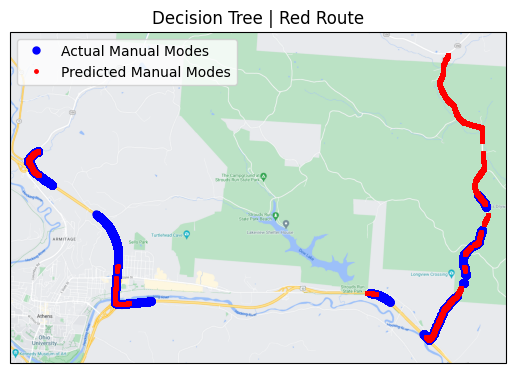

In [26]:

#

minLat = np.min( np.array( redte_list[ 'latitude' ] ) )

maxLat = np.max( np.array( redte_list[ 'latitude' ] ) )

minLon = np.min( np.array( redte_list[ 'longitude' ] ) )

maxLon = np.max( np.array( redte_list[ 'longitude' ] ) )

expansion_coeff = 0.005

#

street_map = GoogleTiles( style = 'street' )

ax = plt.axes( projection = street_map.crs )

ax.set_extent( [ minLon - expansion_coeff , maxLon + expansion_coeff, minLat - expansion_coeff, maxLat + expansion_coeff ], ccrs.PlateCarree() )

ax.add_image(street_map, 14)

#

actual_disengagement_lat_list_test =  redte_list[ redte_list[ 'BinaryDrivingMode' ] == 0 ][ 'latitude' ]

actual_disengagement_lon_list_test =  redte_list[ redte_list[ 'BinaryDrivingMode' ] == 0 ][ 'longitude' ]

#

pred_disengagement_lat_list_test =  redte_list[ redte_list[ 'pred_BinaryDrivingMode' ] == 0 ][ 'latitude' ]

pred_disengagement_lon_list_test =  redte_list[ redte_list[ 'pred_BinaryDrivingMode' ] == 0 ][ 'longitude' ]

#

plt.plot( actual_disengagement_lon_list_test, 
          actual_disengagement_lat_list_test, 
          transform = ccrs.PlateCarree(), 
          marker = 'o', 
          ls = '', 
          color = 'blue',  
          ms = 5, 
          label = 'Actual Manual Modes' )

plt.plot( pred_disengagement_lon_list_test, 
          pred_disengagement_lat_list_test, 
          transform = ccrs.PlateCarree(), 
          marker = 'o', 
          ls = '', 
          color = 'red', 
          ms = 2.5,
          label = 'Predicted Manual Modes' )

plt.title( 'Decision Tree | Red Route' )

plt.legend()

plt.show()


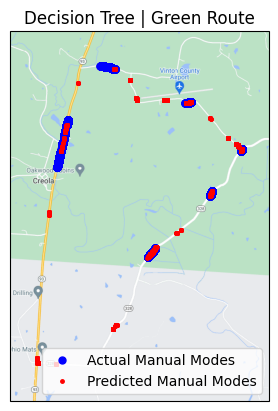

In [27]:
minLat = np.min( np.array( greente_list[ 'latitude' ] ) )

maxLat = np.max( np.array( greente_list[ 'latitude' ] ) )

minLon = np.min( np.array( greente_list[ 'longitude' ] ) )

maxLon = np.max( np.array( greente_list[ 'longitude' ] ) )

expansion_coeff = 0.005

#

street_map = GoogleTiles( style = 'street' )

ax = plt.axes( projection = street_map.crs )

ax.set_extent( [ minLon - expansion_coeff , maxLon + expansion_coeff, minLat - expansion_coeff, maxLat + expansion_coeff ], ccrs.PlateCarree() )

ax.add_image(street_map, 14)

#

actual_disengagement_lat_list_test =  greente_list[ greente_list[ 'BinaryDrivingMode' ] == 0 ][ 'latitude' ]

actual_disengagement_lon_list_test =  greente_list[ greente_list[ 'BinaryDrivingMode' ] == 0 ][ 'longitude' ]

#

pred_disengagement_lat_list_test =  greente_list[ greente_list[ 'pred_BinaryDrivingMode' ] == 0 ][ 'latitude' ]

pred_disengagement_lon_list_test =  greente_list[ greente_list[ 'pred_BinaryDrivingMode' ] == 0 ][ 'longitude' ]

#

plt.plot( actual_disengagement_lon_list_test, 
          actual_disengagement_lat_list_test, 
          transform = ccrs.PlateCarree(), 
          marker = 'o', 
          ls = '', 
          color = 'blue',  
          ms = 5, 
          label = 'Actual Manual Modes' )

plt.plot( pred_disengagement_lon_list_test, 
          pred_disengagement_lat_list_test, 
          transform = ccrs.PlateCarree(), 
          marker = 'o', 
          ls = '', 
          color = 'red', 
          ms = 2.5,
          label = 'Predicted Manual Modes' )

plt.title( 'Decision Tree | Green Route' )

plt.legend()

plt.show()

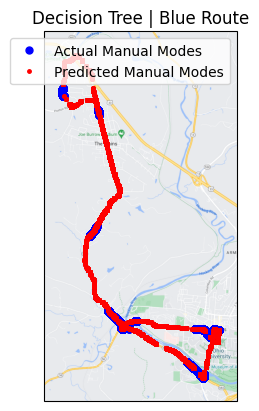

In [28]:
minLat = np.min( np.array( bluete_list[ 'latitude' ] ) )

maxLat = np.max( np.array( bluete_list[ 'latitude' ] ) )

minLon = np.min( np.array( bluete_list[ 'longitude' ] ) )

maxLon = np.max( np.array( bluete_list[ 'longitude' ] ) )

expansion_coeff = 0.005

#

street_map = GoogleTiles( style = 'street' )

ax = plt.axes( projection = street_map.crs )

ax.set_extent( [ minLon - expansion_coeff , maxLon + expansion_coeff, minLat - expansion_coeff, maxLat + expansion_coeff ], ccrs.PlateCarree() )

ax.add_image(street_map, 14)

#

actual_disengagement_lat_list_test =  bluete_list[ bluete_list[ 'BinaryDrivingMode' ] == 0 ][ 'latitude' ]

actual_disengagement_lon_list_test =  bluete_list[ bluete_list[ 'BinaryDrivingMode' ] == 0 ][ 'longitude' ]

#

pred_disengagement_lat_list_test =  bluete_list[ bluete_list[ 'pred_BinaryDrivingMode' ] == 0 ][ 'latitude' ]

pred_disengagement_lon_list_test =  bluete_list[ bluete_list[ 'pred_BinaryDrivingMode' ] == 0 ][ 'longitude' ]

#

plt.plot( actual_disengagement_lon_list_test, 
          actual_disengagement_lat_list_test, 
          transform = ccrs.PlateCarree(), 
          marker = 'o', 
          ls = '', 
          color = 'blue',  
          ms = 5, 
          label = 'Actual Manual Modes' )

plt.plot( pred_disengagement_lon_list_test, 
          pred_disengagement_lat_list_test, 
          transform = ccrs.PlateCarree(), 
          marker = 'o', 
          ls = '', 
          color = 'red', 
          ms = 2.5,
          label = 'Predicted Manual Modes' )

plt.title( 'Decision Tree | Blue Route' )

plt.legend()

plt.show()